# FITTING T1 & T2 COHERENT DECAY 

### 1. LOAD DATA

In [1]:
import glob
import os
from datetime import datetime
import numpy as np

# ==========================================================
# Search configuration
# Each block corresponds to one measurement batch
# =================================================
beta_scale = 1.6468200333233496
search_configs = [
#     {
#         "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06",
        
#         "start": "09-19-00",
#         "stop":  "09-20-00",
#         "decays": np.array([0e3])# In ns (remove 4 for clock cycles)
#     },
    
    
    {
        "data_dir": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06",
        "start": "12-11-00",
        "stop":  "15-27-00",
        "decays": np.array([0.5e3, 1e3, 2.5e3, 5e3, 8e3, 20e3, 50e3, 100e3, 200e3])# In ns (remove 4 for clock cycles)
    },
#     
]

# ==========================================================
# Collect files and assign decay values
# ==========================================================
paired_data = []

for cfg in search_configs:

    start_time = datetime.strptime(cfg["start"], "%H-%M-%S")
    stop_time = datetime.strptime(cfg["stop"], "%H-%M-%S")

    files = []

    for file_path in glob.glob(os.path.join(cfg["data_dir"], "*.hdf5")):

        filename = os.path.basename(file_path)

        if "ECD_decay_sweep" not in filename:
            continue

        try:
            file_time = datetime.strptime(
                filename.split("_")[0],
                "%H-%M-%S"
            )
        except ValueError:
            continue

        if start_time <= file_time <= stop_time:
            files.append(file_path)

    # Keep chronological order within this batch
    files.sort()

    print(f"\nBatch: {cfg['data_dir']}")
    print(f"Found {len(files)} files")

    if len(files) != len(cfg["decays"]):
        raise ValueError(
            f"Expected {len(cfg['decays'])} files, "
            f"but found {len(files)}."
        )

    for decay, file in zip(cfg["decays"], files):
        paired_data.append((decay, file))

# ==========================================================
# Sort by decay time for plotting
# ==========================================================
paired_data.sort(key=lambda x: x[0])

decay_sweep_sorted = [x[0] for x in paired_data]
collected_files_sorted = [x[1] for x in paired_data]

# ==========================================================
# Print result
# ==========================================================
print("\nFiles in decay order:\n")

for decay, file in zip(decay_sweep_sorted, collected_files_sorted):

    if decay >= 1000:
        label = f"{decay/1000:g} us"
    else:
        label = f"{decay:g} ns"

    print(f"{label:>8}  -->  {os.path.basename(file)}")


Batch: C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-06
Found 9 files

Files in decay order:

  500 ns  -->  12-11-32_ECD_decay_sweep.hdf5
    1 us  -->  12-35-17_ECD_decay_sweep.hdf5
  2.5 us  -->  12-59-05_ECD_decay_sweep.hdf5
    5 us  -->  13-22-52_ECD_decay_sweep.hdf5
    8 us  -->  13-46-46_ECD_decay_sweep.hdf5
   20 us  -->  14-10-43_ECD_decay_sweep.hdf5
   50 us  -->  14-35-03_ECD_decay_sweep.hdf5
  100 us  -->  15-00-15_ECD_decay_sweep.hdf5
  200 us  -->  15-26-58_ECD_decay_sweep.hdf5


### 2. PLOT DATA

Loaded 9 characteristic functions.
State array shape: (9, 21, 21)


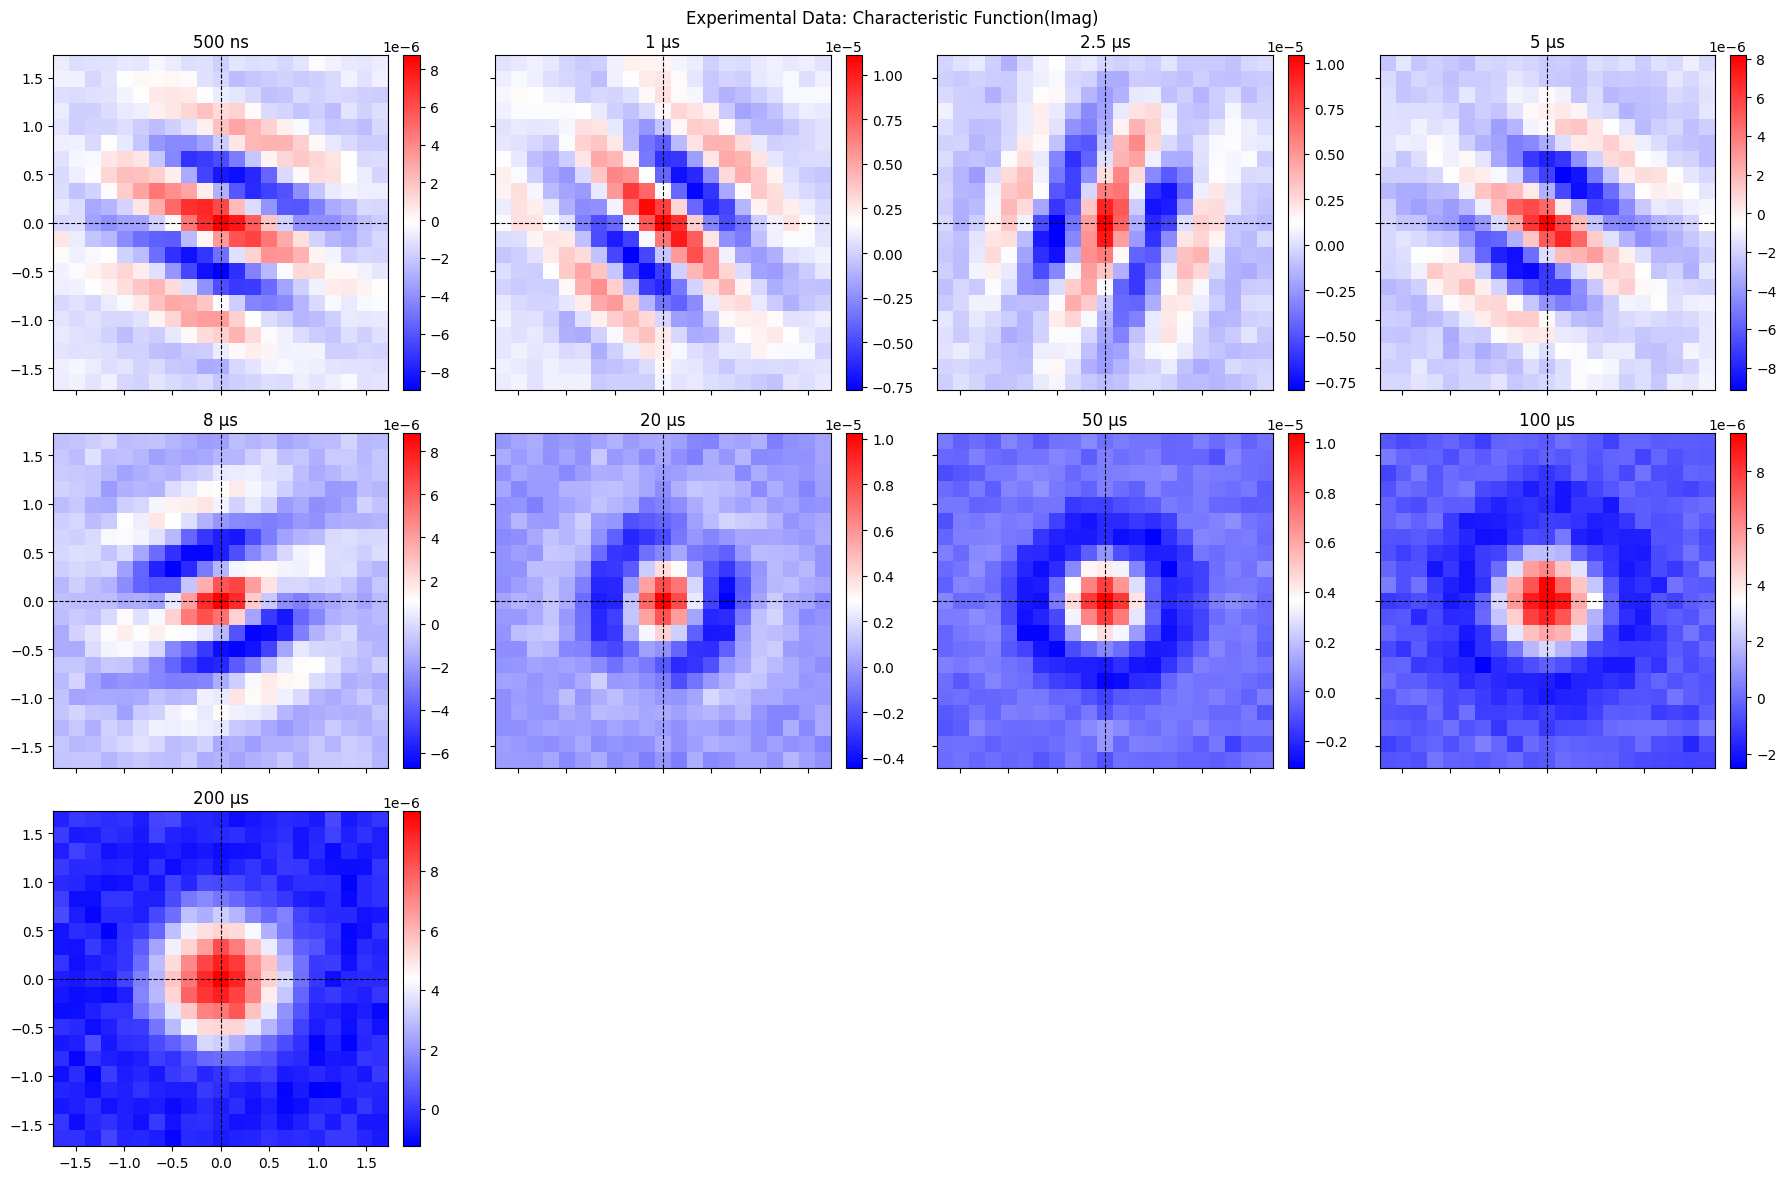

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================================
# Load experimental data
# ==========================================================

state_list = []
x_list = []
y_list = []

for decay, file_path in zip(decay_sweep_sorted, collected_files_sorted):

    with h5py.File(file_path, "r") as data:

        state = np.mean(np.array(data["I"]), axis=0)

        x = beta_scale * np.array(data["ampx_x"])
        y = beta_scale * np.array(data["ampx_y"])

    state_list.append(state)
    x_list.append(x)
    y_list.append(y)

state_list = np.asarray(state_list)
x_list = np.asarray(x_list)
y_list = np.asarray(y_list)

print(f"Loaded {len(state_list)} characteristic functions.")
print("State array shape:", state_list.shape)

# ==========================================================
# Plot function
# ==========================================================

def plot_characteristic_functions(
    charfuncs,
    x_list,
    y_list,
    decay_times,
    title="Characteristic Functions",
):

    n = len(charfuncs)

    cols = 4
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(18,12),
        sharex=True,
        sharey=True,
    )

    axes = np.ravel(axes)

    for i in range(n):

        ax = axes[i]

        im = ax.pcolormesh(
            x_list[i],
            y_list[i],
            charfuncs[i],
            shading="auto",
            cmap="bwr",
        )

        ax.axvline(0, color="k", ls="--", lw=0.8)
        ax.axhline(0, color="k", ls="--", lw=0.8)

        ax.set_aspect("equal")

        decay = decay_times[i]

        if decay >= 1000:
            label = f"{decay/1000:g} μs"
        else:
            label = f"{decay:g} ns"

        ax.set_title(label)

        plt.colorbar(
            im,
            ax=ax,
            fraction=0.046,
            pad=0.04,
        )

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# ==========================================================
# Plot experiment
# ==========================================================

plot_characteristic_functions(
    state_list,
    x_list,
    y_list,
    decay_sweep_sorted,
    # title="Experimental Data: Characteristic Function(Real)",
    title="Experimental Data: Characteristic Function(Imag)",
)

### 3. GENERATE SIMULATION FUNCTIONS

In [ ]:
import numpy as np
import qutip as qt
from scipy.ndimage import rotate

# ==========================================================
# Select component
# ==========================================================

# Set Imag_part = True if fitting imaginary component
Imag_part = False


# ==========================================================
# Hilbert space
# ==========================================================

N_c = 30 # 

a = qt.destroy(N_c)

# ==========================================================
# Experimental beta grid
# ==========================================================

x = x_list[0]
y = y_list[0]

Nx = len(x)
Ny = len(y)

# ==========================================================
# Precompute displacement operators
# ==========================================================

print("Precomputing displacement operators...")

D_ops = [
    qt.displace(N_c, xr + 1j*yi)
    for yi in y
    for xr in x
]

print("Done.")

# ==========================================================
# Simulation
# ==========================================================

def simulate_characteristic_functions(
    T1,
    T2,
    detuning_MHz=0.0,
    angle_offset=0.0,
    alpha=3.0,
    dt=100,
):
    """
    Parameters
    ----------
    T1,T2 : ns

    detuning_MHz :
        Cavity detuning in MHz.

    angle_offset :
        Constant rotation applied AFTER simulation.

    alpha :
        Initial coherent amplitude.
    """

    rho0 = qt.coherent_dm(N_c, alpha)

    gamma1 = 1 / T1

    gamma_phi = max(
        0,
        1 / T2 - 1 / (2 * T1),
    )

    c_ops = [
        np.sqrt(gamma1) * a
    ]

    if gamma_phi > 0:

        c_ops.append(
            np.sqrt(2 * gamma_phi) * a.dag() * a
        )

    # ------------------------------------------------------
    # Hamiltonian
    # ------------------------------------------------------

    omega =  2 * np.pi * detuning_MHz / 1000.0

    H = omega * a.dag() * a

    exp_times = np.asarray(decay_sweep_sorted)

    t_dense = np.arange(
        0,
        exp_times.max() + dt,
        dt,
    )

    result = qt.mesolve(
        H,
        rho0,
        t_dense,
        c_ops=c_ops,
        options={
            "nsteps": 50000,
        },
    )

    states = []

    for t in exp_times:

        idx = np.argmin(
            np.abs(
                t_dense - t
            )
        )

        states.append(
            result.states[idx]
        )

    charfunc = []

    for rho in states:

        # vals = qt.expect(
        #     D_ops,
        #     rho,
        # ).reshape(
        #     Ny,
        #     Nx,
        # )
        vals = np.asarray( qt.expect( D_ops, rho, ) ).reshape( Ny, Nx, )
        # ---------------------------------------------
        # Choose Real or Imaginary globally
        # ---------------------------------------------

        if Imag_part:

            img = np.imag(vals)

        else:

            img = -np.real(vals)

        # ---------------------------------------------
        # Constant offset only
        # ---------------------------------------------

        if abs(angle_offset) > 1e-9:

            img = rotate(
                img,
                angle_offset,
                reshape=False,
                order=1,
                mode="nearest",
            )

        charfunc.append(img)

    return np.asarray(charfunc)

print("Simulation function ready.")

print()

if Imag_part:
    print(">>> Using Imaginary part")
else:
    print(">>> Using Real part")

Precomputing displacement operators...
Done.
Simulation function ready.

>>> Using Real part


### 4. SIMULATE FOR GIVEN CAVITY T1 & T2


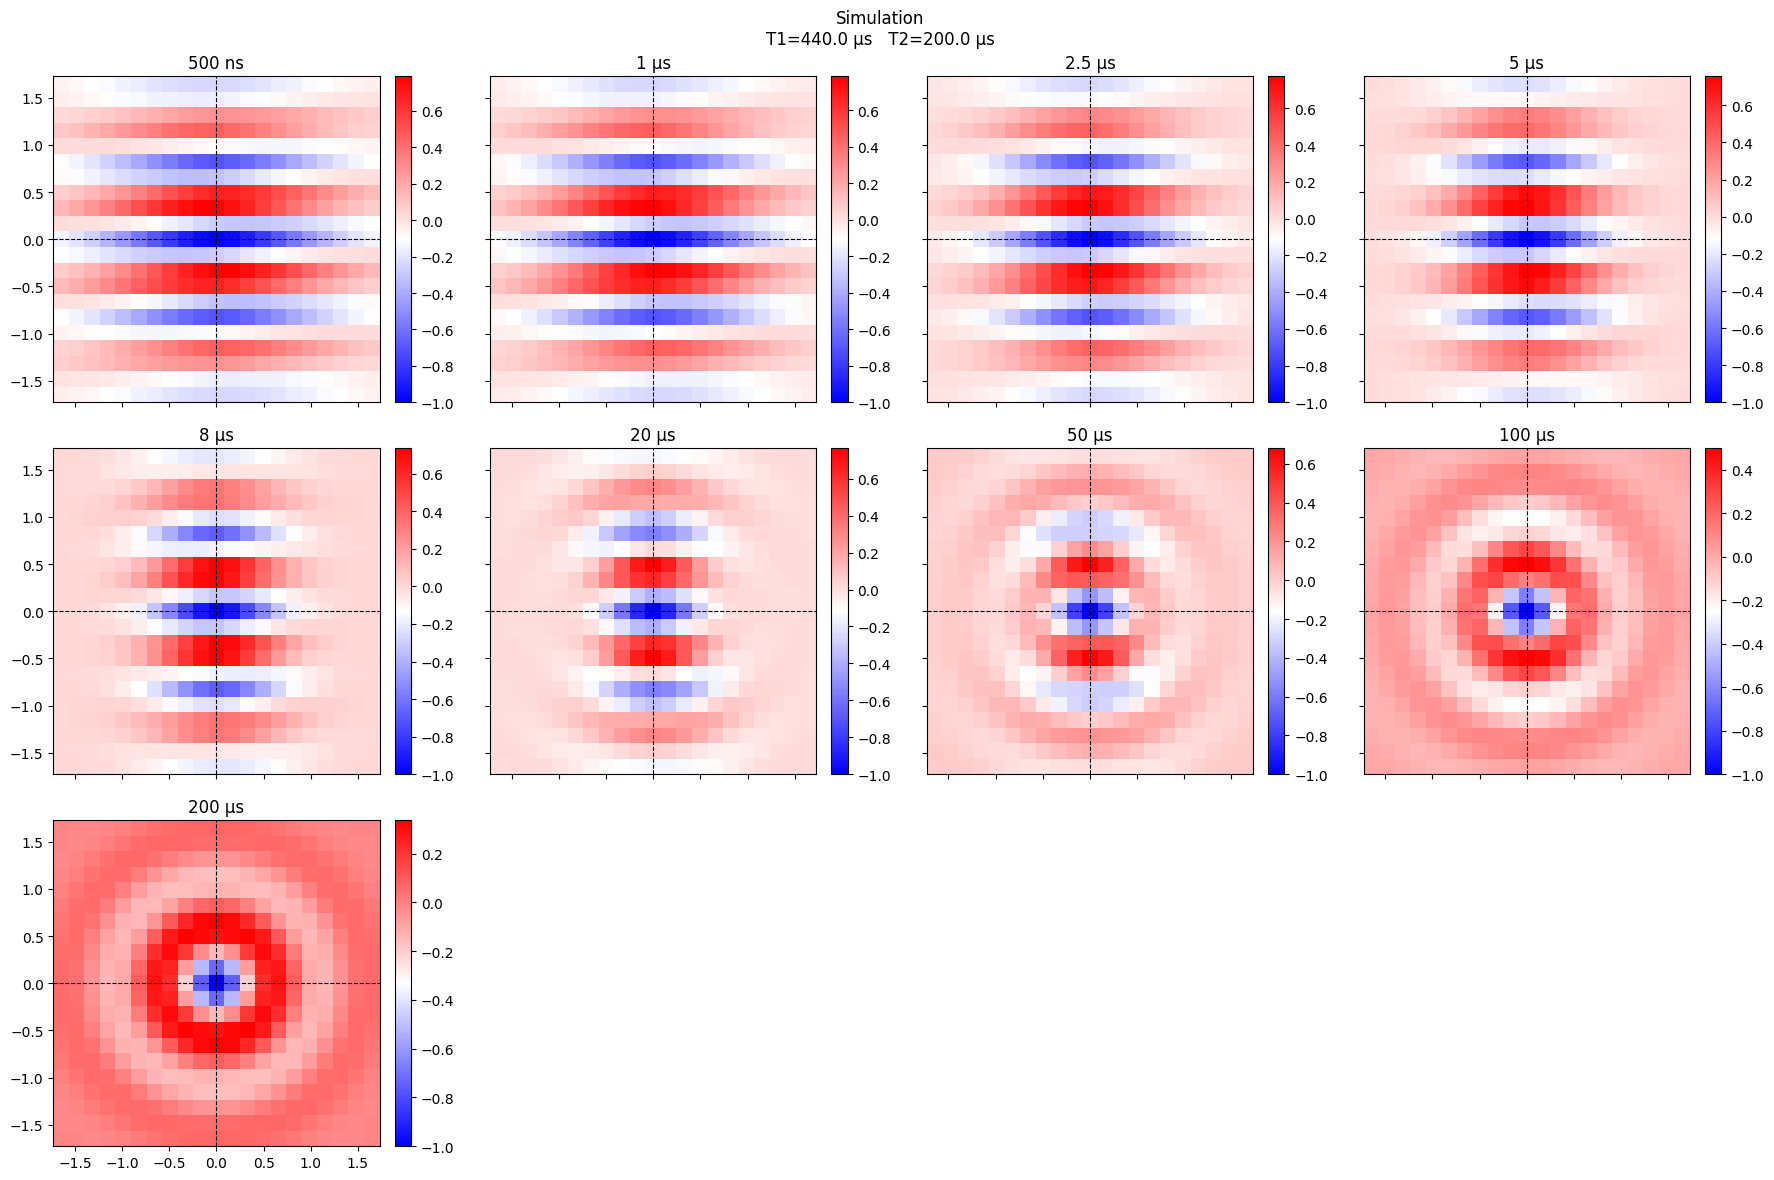

In [4]:
T1 = 110_000.0*4 #in ns
T2 = 50_000.0*4 #in ns

charfunc_sim = simulate_characteristic_functions(
    T1=T1,
    T2=T2,
    detuning_MHz=0.0,
    angle_offset=-2.0,
    alpha=3.9,
    
)

plot_characteristic_functions(
    charfunc_sim,
    x_list,
    y_list,
    decay_sweep_sorted,
    title=f"Simulation\nT1={T1/1000:.1f} μs   T2={T2/1000:.1f} μs",
)

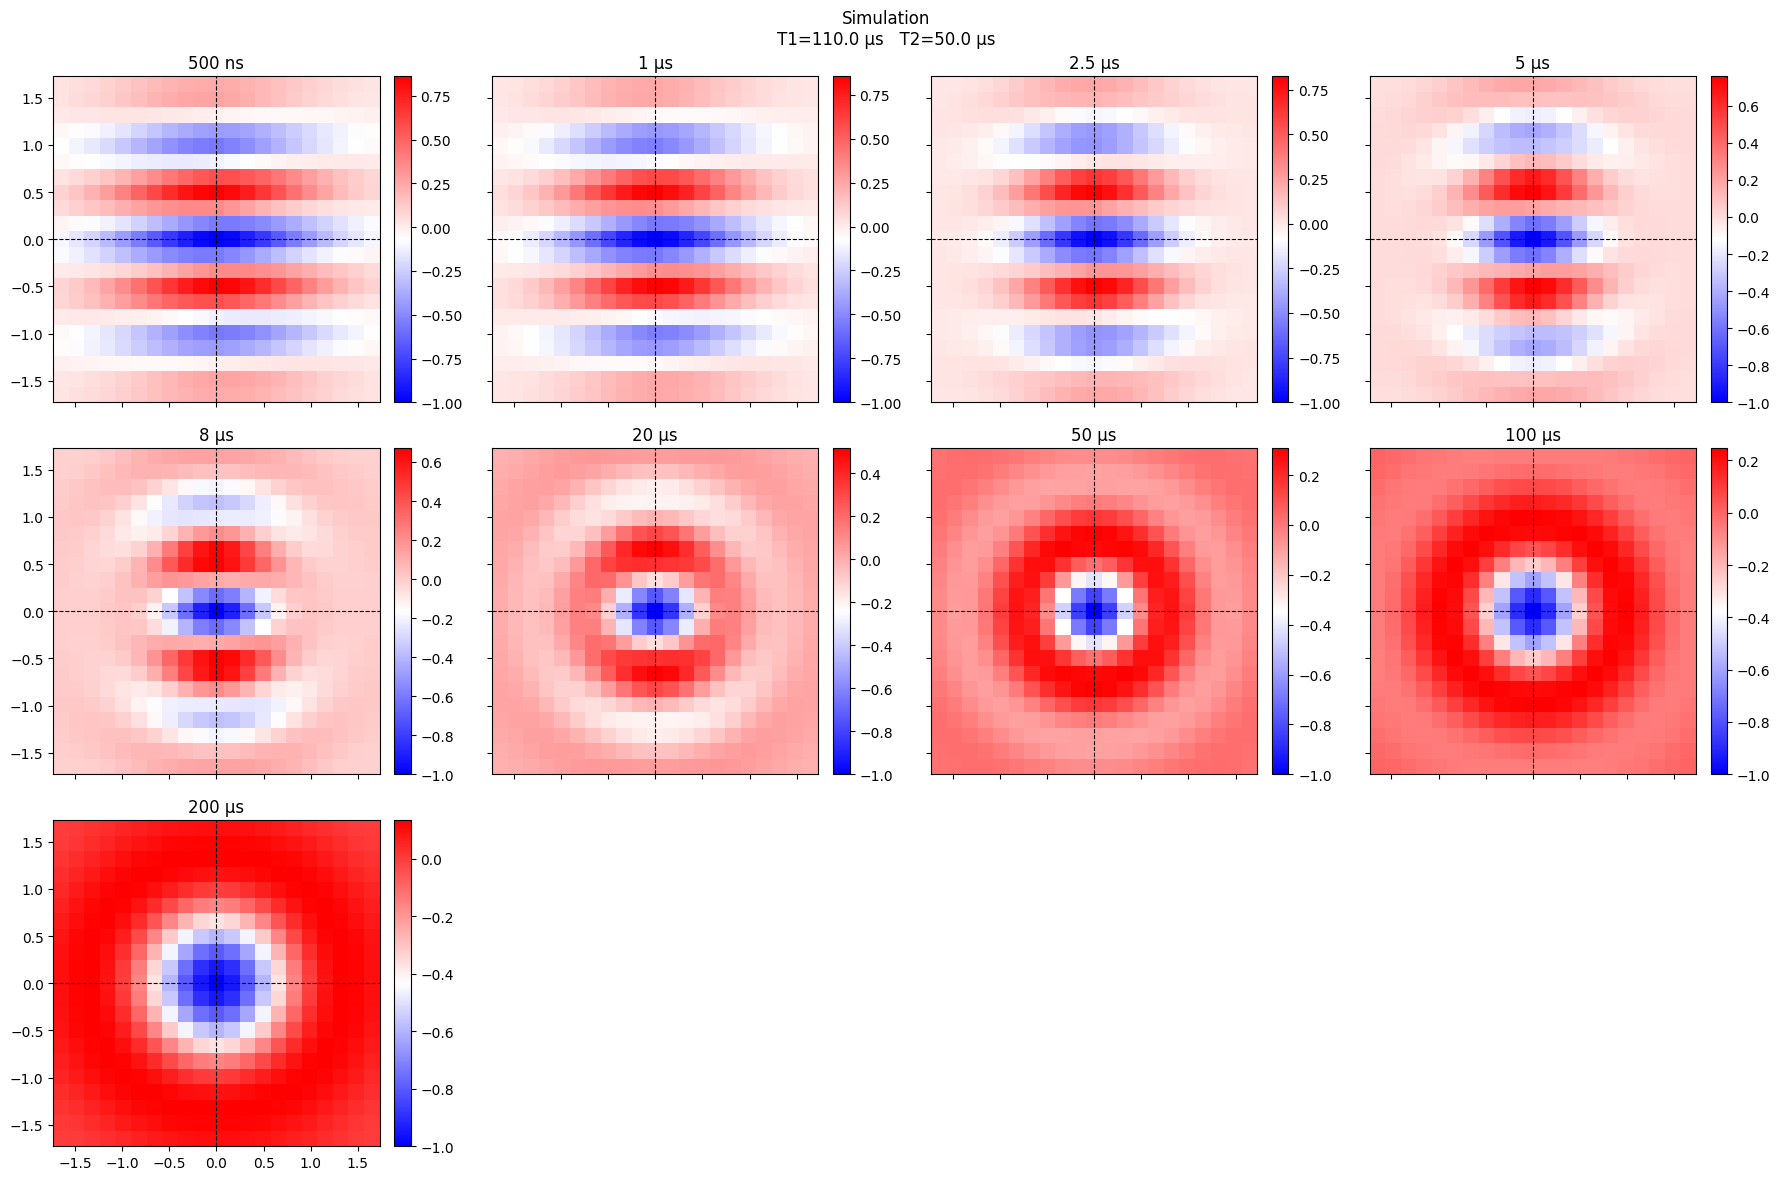

In [5]:
T1 = 110_000.0 #in ns
T2 = 50_000.0 #in ns

charfunc_sim = simulate_characteristic_functions(
    T1=T1,
    T2=T2,
    detuning_MHz=0.0,
    angle_offset=-2.0,
    alpha=3.0,
    
)

plot_characteristic_functions(
    charfunc_sim,
    x_list,
    y_list,
    decay_sweep_sorted,
    title=f"Simulation\nT1={T1/1000:.1f} μs   T2={T2/1000:.1f} μs",
)

### 5. DEFINE METRIC FOR COMPARISON AND FITTING ANGLES

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate

# ==========================================================
# Comparison settings
# ==========================================================

comparison_radius = 2.5

# Full search interval for the FIRST image
rotation_angles = np.linspace(
    -180,
    180,
    361,
)

X, Y = np.meshgrid(
    x_list[0],
    y_list[0],
)

mask = (
    X**2 + Y**2
) <= comparison_radius**2


# ==========================================================
# Affine fit
# ==========================================================

def affine_fit(
    exp_img,
    sim_img,
):
    """
    Fits

        exp ≈ a*sim + b

    over the comparison mask.
    """

    exp = exp_img[mask].ravel()
    sim = sim_img[mask].ravel()

    A = np.vstack([
        sim,
        np.ones_like(sim),
    ]).T

    a, b = np.linalg.lstsq(
        A,
        exp,
        rcond=None,
    )[0]

    sim_fit = a*sim_img + b

    return sim_fit, a, b


# ==========================================================
# Correlation
# ==========================================================

def correlation(
    exp_img,
    sim_img,
):

    exp = exp_img[mask].copy()
    sim = sim_img[mask].copy()

    exp -= exp.mean()
    sim -= sim.mean()

    exp /= np.linalg.norm(exp)
    sim /= np.linalg.norm(sim)

    return np.sum(exp*sim)


# ==========================================================
# Search optimal angle
# ==========================================================

def best_rotated_simulation(
    exp_img,
    sim_img,
    candidate_angles=None,
):

    if candidate_angles is None:
        candidate_angles = rotation_angles

    best_overlap = -np.inf
    best_angle = candidate_angles[0]
    best_sim = None

    for angle in candidate_angles:

        sim_rot = rotate(
            sim_img,
            angle,
            reshape=False,
            order=1,
            mode="nearest",
        )

        sim_fit, _, _ = affine_fit(
            exp_img,
            sim_rot,
        )

        overlap = correlation(
            exp_img,
            sim_fit,
        )

        if overlap > best_overlap:

            best_overlap = overlap
            best_angle = angle
            best_sim = sim_fit

    return (
        best_sim,
        best_overlap,
        best_angle,
    )


# ==========================================================
# Cost function
# ==========================================================

def residue(
    exp_data,
    sim_data,
):

    costs = []

    previous_angle = None

    for exp, sim in zip(
        exp_data,
        sim_data,
    ):

        # ---------------------------------------------
        # First image:
        # search entire interval
        # ---------------------------------------------

        if previous_angle is None:

            candidate_angles = rotation_angles

        # ---------------------------------------------
        # Remaining images:
        # constrain search to ±90° around previous angle
        # ---------------------------------------------

        else:

            candidate_angles = rotation_angles[
                np.abs(rotation_angles - previous_angle) <= 90
            ]

            # Safety
            if len(candidate_angles) == 0:
                candidate_angles = np.array([previous_angle])

        sim_fit, overlap, angle = best_rotated_simulation(
            exp,
            sim,
            candidate_angles,
        )

        previous_angle = angle

        diff = (
            exp[mask]
            -
            sim_fit[mask]
        )

        rms = np.sqrt(
            np.mean(diff**2)
        )

        rms /= np.std(
            exp[mask]
        )

        cost = (
            0.4*rms
            +
            0.6*(1-overlap)
        )

        costs.append(cost)

    return np.mean(costs)


# ==========================================================
# Cost function WITHOUT image rotation
#
# Used during the final optimization.
#
# The Hamiltonian is responsible for the rotation.
# ==========================================================

def residue_no_rotation(
    exp_data,
    sim_data,
):

    costs = []

    for exp, sim in zip(
        exp_data,
        sim_data,
    ):

        sim_fit, _, _ = affine_fit(
            exp,
            sim,
        )

        overlap = correlation(
            exp,
            sim_fit,
        )

        diff = (
            exp[mask]
            -
            sim_fit[mask]
        )

        rms = np.sqrt(
            np.mean(diff**2)
        )

        rms /= np.std(
            exp[mask]
        )

        cost = (
            0.4*rms
            +
            0.6*(1-overlap)
        )

        costs.append(cost)

    return np.mean(costs)


# ==========================================================
# Obtain all optimal angles
# ==========================================================

def extract_rotation_angles(
    exp_data,
    sim_data,
):

    angles = []
    overlaps = []

    previous_angle = None

    for exp, sim in zip(
        exp_data,
        sim_data,
    ):

        if previous_angle is None:

            candidate_angles = rotation_angles

        else:

            candidate_angles = rotation_angles[
                np.abs(rotation_angles - previous_angle) <= 90
            ]

            if len(candidate_angles) == 0:
                candidate_angles = np.array([previous_angle])

        _, overlap, angle = best_rotated_simulation(
            exp,
            sim,
            candidate_angles,
        )

        previous_angle = angle

        angles.append(angle)
        overlaps.append(overlap)

    return (
        np.asarray(angles),
        np.asarray(overlaps),
    )


# ==========================================================
# Comparison figure
# ==========================================================

def compare_experiment_simulation(
    exp_data,
    sim_data,
    rotate_images=True,
):

    if rotate_images:

        angles, overlaps = extract_rotation_angles(
            exp_data,
            sim_data,
        )

    else:

        overlaps = []

        angles = np.zeros(len(exp_data))

        for exp, sim in zip(
            exp_data,
            sim_data,
        ):

            sim_fit, _, _ = affine_fit(
                exp,
                sim,
            )

            overlaps.append(
                correlation(
                    exp,
                    sim_fit,
                )
            )

        overlaps = np.asarray(overlaps)

    n = len(exp_data)

    fig, axes = plt.subplots(
        n,
        3,
        figsize=(10,3*n),
    )

    if n == 1:
        axes = np.array([axes])

    previous_angle = None

    for i in range(n):

        if rotate_images:

            if previous_angle is None:

                candidate_angles = rotation_angles

            else:

                candidate_angles = rotation_angles[
                    np.abs(rotation_angles - previous_angle) <= 90
                ]

                if len(candidate_angles) == 0:
                    candidate_angles = np.array([previous_angle])

            sim_fit, _, angle = best_rotated_simulation(
                exp_data[i],
                sim_data[i],
                candidate_angles,
            )

            previous_angle = angle

            sim_title = f"Simulation ({angle:+.1f}°)"

        else:

            sim_fit, _, _ = affine_fit(
                exp_data[i],
                sim_data[i],
            )

            sim_title = "Simulation"

        diff = exp_data[i] - sim_fit

        images = [
            exp_data[i],
            sim_fit,
            diff,
        ]

        titles = [
            "Experiment",
            sim_title,
            "Residual",
        ]

        for j in range(3):

            ax = axes[i,j]

            if j < 2:

                im = ax.pcolormesh(
                    x_list[i],
                    y_list[i],
                    images[j],
                    shading="auto",
                    cmap="bwr",
                )

            else:

                vmax = np.percentile(
                    np.abs(diff),
                    99,
                )

                im = ax.pcolormesh(
                    x_list[i],
                    y_list[i],
                    diff,
                    shading="auto",
                    cmap="bwr",
                    vmin=-vmax,
                    vmax=vmax,
                )

            ax.axvline(
                0,
                color="k",
                ls="--",
                lw=0.8,
            )

            ax.axhline(
                0,
                color="k",
                ls="--",
                lw=0.8,
            )

            ax.set_aspect("equal")

            ax.set_title(
                titles[j]
            )

            plt.colorbar(
                im,
                ax=ax,
                fraction=0.046,
            )

        axes[i,2].set_xlabel(
            f"corr={overlaps[i]:.3f}"
        )

    plt.tight_layout()

    plt.show()

    print(
        "\nAverage overlap:",
        overlaps.mean(),
    )

    if rotate_images:

        print(
            "Cost:",
            residue(
                exp_data,
                sim_data,
            ),
        )

    else:

        print(
            "Cost:",
            residue_no_rotation(
                exp_data,
                sim_data,
            ),
        )

    return angles, overlaps

### 6. FIT ALPHA

Searching alpha...

Best coherent state
alpha = 3.2000
angle = 20.00 deg


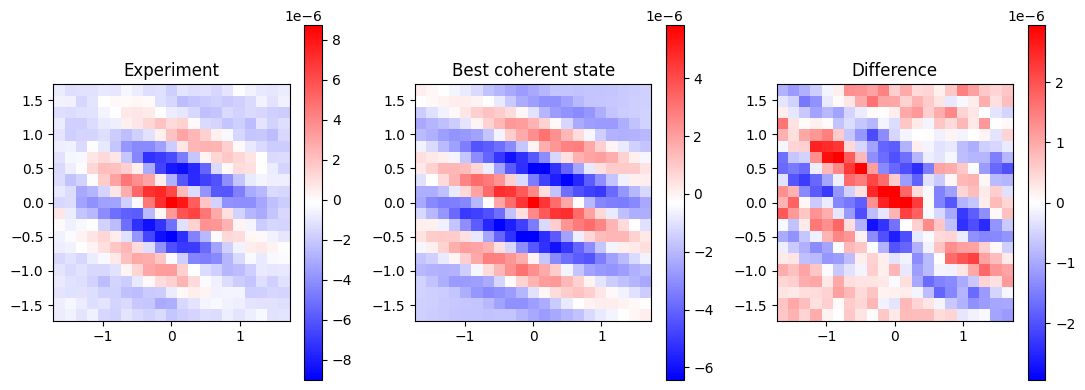

In [7]:
import matplotlib.pyplot as plt
from scipy.ndimage import rotate

# ==========================================================
# User settings
# ==========================================================

alpha_values = np.linspace(
    2,
    6,
    121,
)

rotation_values = np.linspace(
    -20,
    20,
    32,
)

# ==========================================================
# First experimental image
# ==========================================================

exp_img = state_list[0]

# ==========================================================
# Cost function
# ==========================================================

best_cost = np.inf

best_alpha = None
best_angle = None
best_sim = None

print("Searching alpha...")

for alpha in alpha_values:

    sim = simulate_characteristic_functions(
        T1=1e9,
        T2=1e9,
        alpha=alpha,
    )[0]

    for angle in rotation_values:

        sim_rot = rotate(
            sim,
            angle,
            reshape=False,
            order=1,
            mode="nearest",
        )

        sim_fit, _, _ = affine_fit(
            exp_img,
            sim_rot,
        )

        diff = exp_img[mask] - sim_fit[mask]

        cost = np.sqrt(
            np.mean(diff**2)
        )

        if cost < best_cost:

            best_cost = cost
            best_alpha = alpha
            best_angle = angle
            best_sim = sim_fit

print()
print("====================================")
print("Best coherent state")
print("====================================")
print(f"alpha = {best_alpha:.4f}")
print(f"angle = {best_angle:.2f} deg")

# ==========================================================
# Plot
# ==========================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(11,4),
)

titles = [
    "Experiment",
    "Best coherent state",
    "Difference",
]

images = [
    exp_img,
    best_sim,
    exp_img-best_sim,
]

for ax,title,img in zip(
    axes,
    titles,
    images,
):

    if title=="Difference":

        vmax=np.percentile(
            np.abs(img),
            99,
        )

        im=ax.pcolormesh(
            x_list[0],
            y_list[0],
            img,
            shading="auto",
            cmap="bwr",
            vmin=-vmax,
            vmax=vmax,
        )

    else:

        im=ax.pcolormesh(
            x_list[0],
            y_list[0],
            img,
            shading="auto",
            cmap="bwr",
        )

    ax.set_title(title)
    ax.set_aspect("equal")
    plt.colorbar(im,ax=ax)

plt.tight_layout()
plt.show()

# ==========================================================
# Save value
# ==========================================================

initial_alpha = best_alpha

### 7. RUN GRID SEARCH FOR COARSE FITTING

T1 = 50.00 μs
T1 = 100.00 μs
T1 = 150.00 μs
T1 = 200.00 μs
T1 = 250.00 μs
T1 = 300.00 μs

Best parameters
----------------
T1 = 100.000 μs
T2 = 76.000 μs
Residue = 0.21589


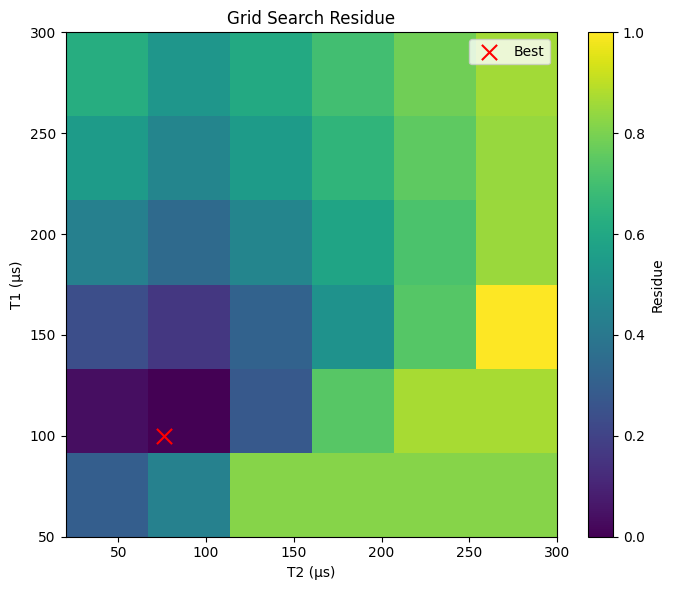

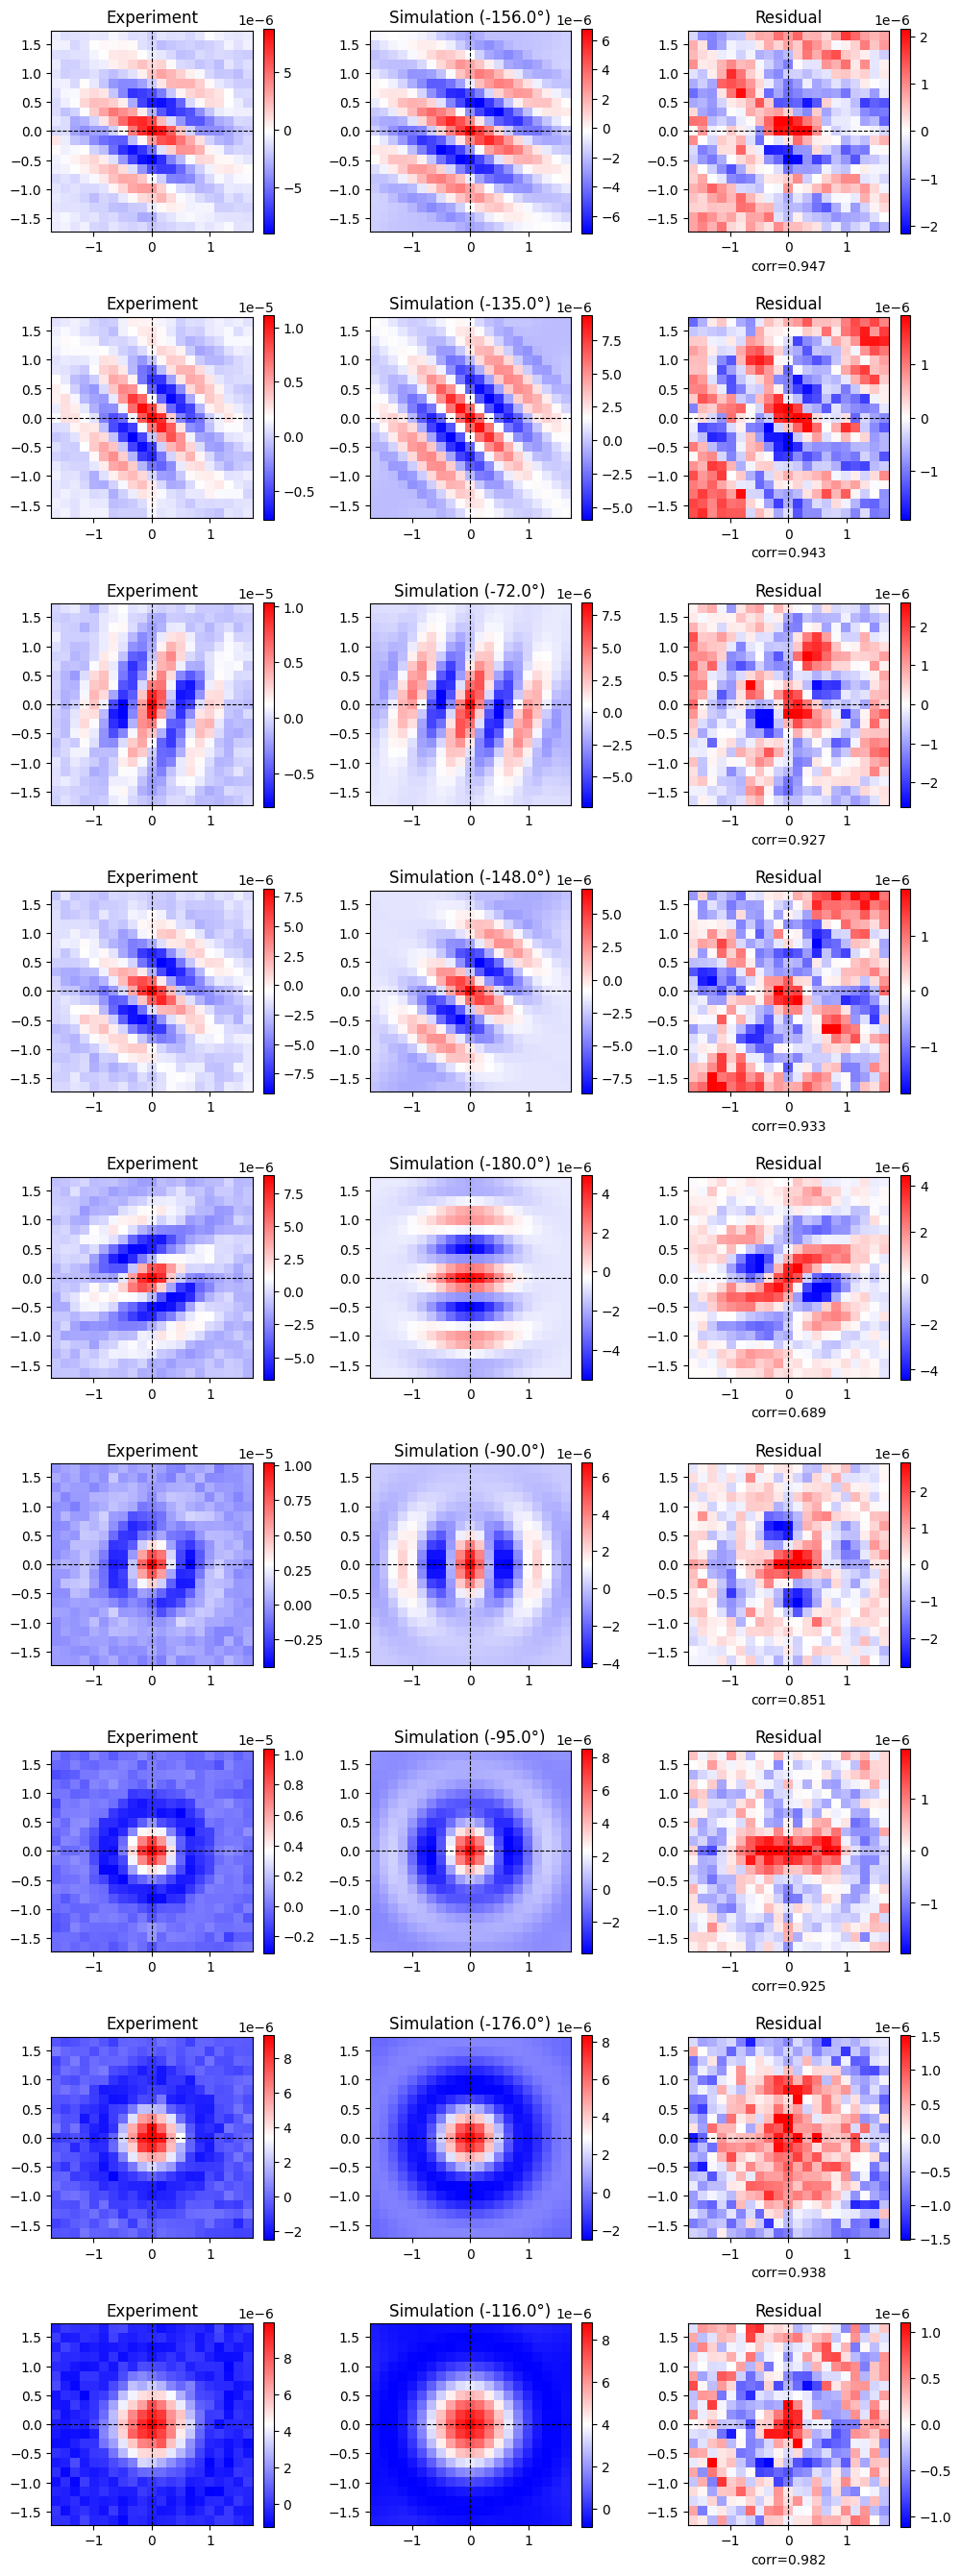


Average overlap: 0.9037575810940667
Cost: 0.2158941407918083

Optimal image rotations:
  500 ns   -156.00°   corr=0.947
    1 μs   -135.00°   corr=0.943
  2.5 μs   -72.00°   corr=0.927
    5 μs   -148.00°   corr=0.933
    8 μs   -180.00°   corr=0.689
   20 μs   -90.00°   corr=0.851
   50 μs   -95.00°   corr=0.925
  100 μs   -176.00°   corr=0.938
  200 μs   -116.00°   corr=0.982


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Parameter grid
# ==========================================================

T1_values = np.linspace(50_000, 300_000, 6) # in ns
T2_values = np.linspace(20_000, 300_000, 6)   # in ns

cost = np.zeros((len(T1_values), len(T2_values)))

# ==========================================================
# Grid search
# ==========================================================

for i, T1 in enumerate(T1_values):

    print(f"T1 = {T1/1000:.2f} μs")

    for j, T2 in enumerate(T2_values):

        sim = simulate_characteristic_functions(
            T1=T1,
            T2=T2,
            alpha=initial_alpha,
        )

        cost[i,j] = residue(
            state_list,
            sim,
        )

# ==========================================================
# Best point
# ==========================================================

best = np.unravel_index(
    np.argmin(cost),
    cost.shape,
)

best_T1 = T1_values[best[0]]
best_T2 = T2_values[best[1]]

print()
print("Best parameters")
print("----------------")
print(f"T1 = {best_T1/1000:.3f} μs")
print(f"T2 = {best_T2/1000:.3f} μs")
print(f"Residue = {cost[best]:.5f}")

# ==========================================================
# Plot landscape
# ==========================================================

plt.figure(figsize=(7,6))

plt.imshow(
    cost,
    origin="lower",
    aspect="auto",
    extent=[
        T2_values[0]/1000,
        T2_values[-1]/1000,
        T1_values[0]/1000,
        T1_values[-1]/1000,
    ],
)

plt.scatter(
    best_T2/1000,
    best_T1/1000,
    marker="x",
    s=120,
    c="red",
    label="Best",
)

plt.xlabel("T2 (μs)")
plt.ylabel("T1 (μs)")
plt.title("Grid Search Residue")

plt.colorbar(label="Residue")

plt.legend()

plt.tight_layout()

plt.show()

# ==========================================================
# Compare best simulation
# ==========================================================

best_sim = simulate_characteristic_functions(
    best_T1,
    best_T2,
    alpha=initial_alpha,
)
compare_experiment_simulation(
    state_list,
    best_sim,
)

# ----------------------------------------------------------
# Save fitted angles for later use
# ----------------------------------------------------------

best_angles, best_overlaps = extract_rotation_angles(
    state_list,
    best_sim,
)

print("\nOptimal image rotations:")

for t, angle, overlap in zip(
    decay_sweep_sorted,
    best_angles,
    best_overlaps,
):

    if t >= 1000:
        label = f"{t/1000:g} μs"
    else:
        label = f"{t:g} ns"

    print(
        f"{label:>8}   "
        f"{angle:+6.2f}°   "
        f"corr={overlap:.3f}"
    )


### 8. DEFINE COST FUNCTION AND FIT DETUNING

Estimated cavity detuning
Initial angle offset : -140.351 deg
Rotation slope       : 1.652 deg/us
Detuning             : 0.004588 MHz


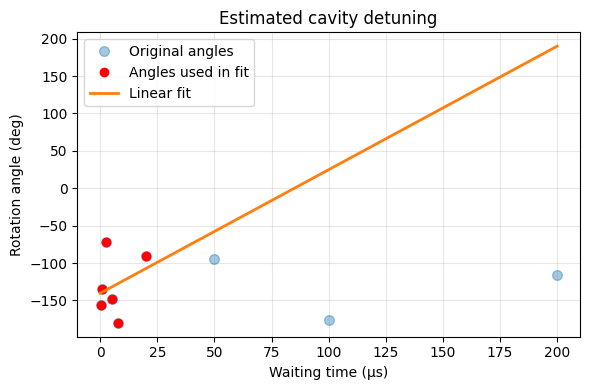


Initial parameters for optimization
-----------------------------------
T1       = 100.000 μs
T2       = 76.000 μs
Detuning = 0.004588 MHz
Offset   = -140.351 deg


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ==========================================================
# User settings
# ==========================================================

# Number of earliest points used for the fit.
# Later points become unreliable because of dephasing.
num_points_fit =6

# ==========================================================
# Data
# ==========================================================

times_ns = np.asarray(decay_sweep_sorted)
times_us = times_ns / 1000

angles_deg = np.asarray(best_angles)

fit_times = times_us[:num_points_fit]
fit_angles = angles_deg[:num_points_fit]

# ==========================================================
# Shift angles close to the first point
#
# We do NOT unwrap.
# We simply move every angle by ±360° so that it stays
# close to the first measured angle.
# ==========================================================

reference = fit_angles[0]

fit_angles_corrected = fit_angles.copy()

for i in range(len(fit_angles_corrected)):

    while fit_angles_corrected[i] - reference > 180:
        fit_angles_corrected[i] -= 360

    while fit_angles_corrected[i] - reference < -180:
        fit_angles_corrected[i] += 360

# ==========================================================
# Linear model
# ==========================================================

def angle_model(t, offset_deg, slope_deg_per_us):
    return offset_deg + slope_deg_per_us*t

popt, pcov = curve_fit(
    angle_model,
    fit_times,
    fit_angles_corrected,
)

offset_deg = popt[0]
slope_deg_per_us = popt[1]

# ==========================================================
# Convert slope to detuning
# ==========================================================

# 360 degrees correspond to one oscillation.

detuning_MHz = slope_deg_per_us / 360.0

print("=====================================")
print("Estimated cavity detuning")
print("=====================================")
print(f"Initial angle offset : {offset_deg:.3f} deg")
print(f"Rotation slope       : {slope_deg_per_us:.3f} deg/us")
print(f"Detuning             : {detuning_MHz:.6f} MHz")

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(6,4))

plt.plot(
    times_us,
    angles_deg,
    "o",
    ms=7,
    alpha=0.4,
    label="Original angles",
)

plt.plot(
    fit_times,
    fit_angles_corrected,
    "ro",
    label="Angles used in fit",
)

tt = np.linspace(
    0,
    times_us.max(),
    300,
)

plt.plot(
    tt,
    angle_model(tt, *popt),
    lw=2,
    label="Linear fit",
)

plt.xlabel("Waiting time (μs)")
plt.ylabel("Rotation angle (deg)")
plt.title("Estimated cavity detuning")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# ==========================================================
# Values to use in optimizer
# ==========================================================

initial_T1 = best_T1
initial_T2 = best_T2
initial_detuning = detuning_MHz
initial_angle_offset = offset_deg

print("\nInitial parameters for optimization")
print("-----------------------------------")
print(f"T1       = {initial_T1/1000:.3f} μs")
print(f"T2       = {initial_T2/1000:.3f} μs")
print(f"Detuning = {initial_detuning:.6f} MHz")
print(f"Offset   = {initial_angle_offset:.3f} deg")

### 9. RUN OPTIMIZATION

Starting optimization
T1       = 100.000 μs
T2       = 76.000 μs
Detuning = 0.004588 MHz
Angle offset fixed = -140.35°
T1= 100.00 μs   T2=  76.00 μs   Δ=  0.0046 MHz   alpha=  3.2000 cost=0.411821
T1= 105.00 μs   T2=  76.00 μs   Δ=  0.0046 MHz   alpha=  3.2000 cost=0.411481
T1= 100.00 μs   T2=  79.80 μs   Δ=  0.0046 MHz   alpha=  3.2000 cost=0.416520
T1= 100.00 μs   T2=  76.00 μs   Δ=  0.0048 MHz   alpha=  3.2000 cost=0.411113
T1= 103.33 μs   T2=  72.20 μs   Δ=  0.0047 MHz   alpha=  3.2000 cost=0.406357
T1= 105.00 μs   T2=  68.40 μs   Δ=  0.0048 MHz   alpha=  3.2000 cost=0.401605
T1= 106.67 μs   T2=  70.93 μs   Δ=  0.0049 MHz   alpha=  3.2000 cost=0.404687
T1= 102.78 μs   T2=  67.56 μs   Δ=  0.0051 MHz   alpha=  3.2000 cost=0.399447
T1= 101.67 μs   T2=  63.33 μs   Δ=  0.0054 MHz   alpha=  3.2000 cost=0.393248
T1= 108.89 μs   T2=  59.11 μs   Δ=  0.0052 MHz   alpha=  3.2000 cost=0.389911
T1= 113.33 μs   T2=  50.67 μs   Δ=  0.0054 MHz   alpha=  3.2000 cost=0.381168
T1= 106.67 μs   T2=  50

C:\Users\qcrew\AppData\Local\Temp\ipykernel_39508\3414879942.py:104: RuntimeWarning: Maximum number of iterations has been exceeded.
  result = minimize(


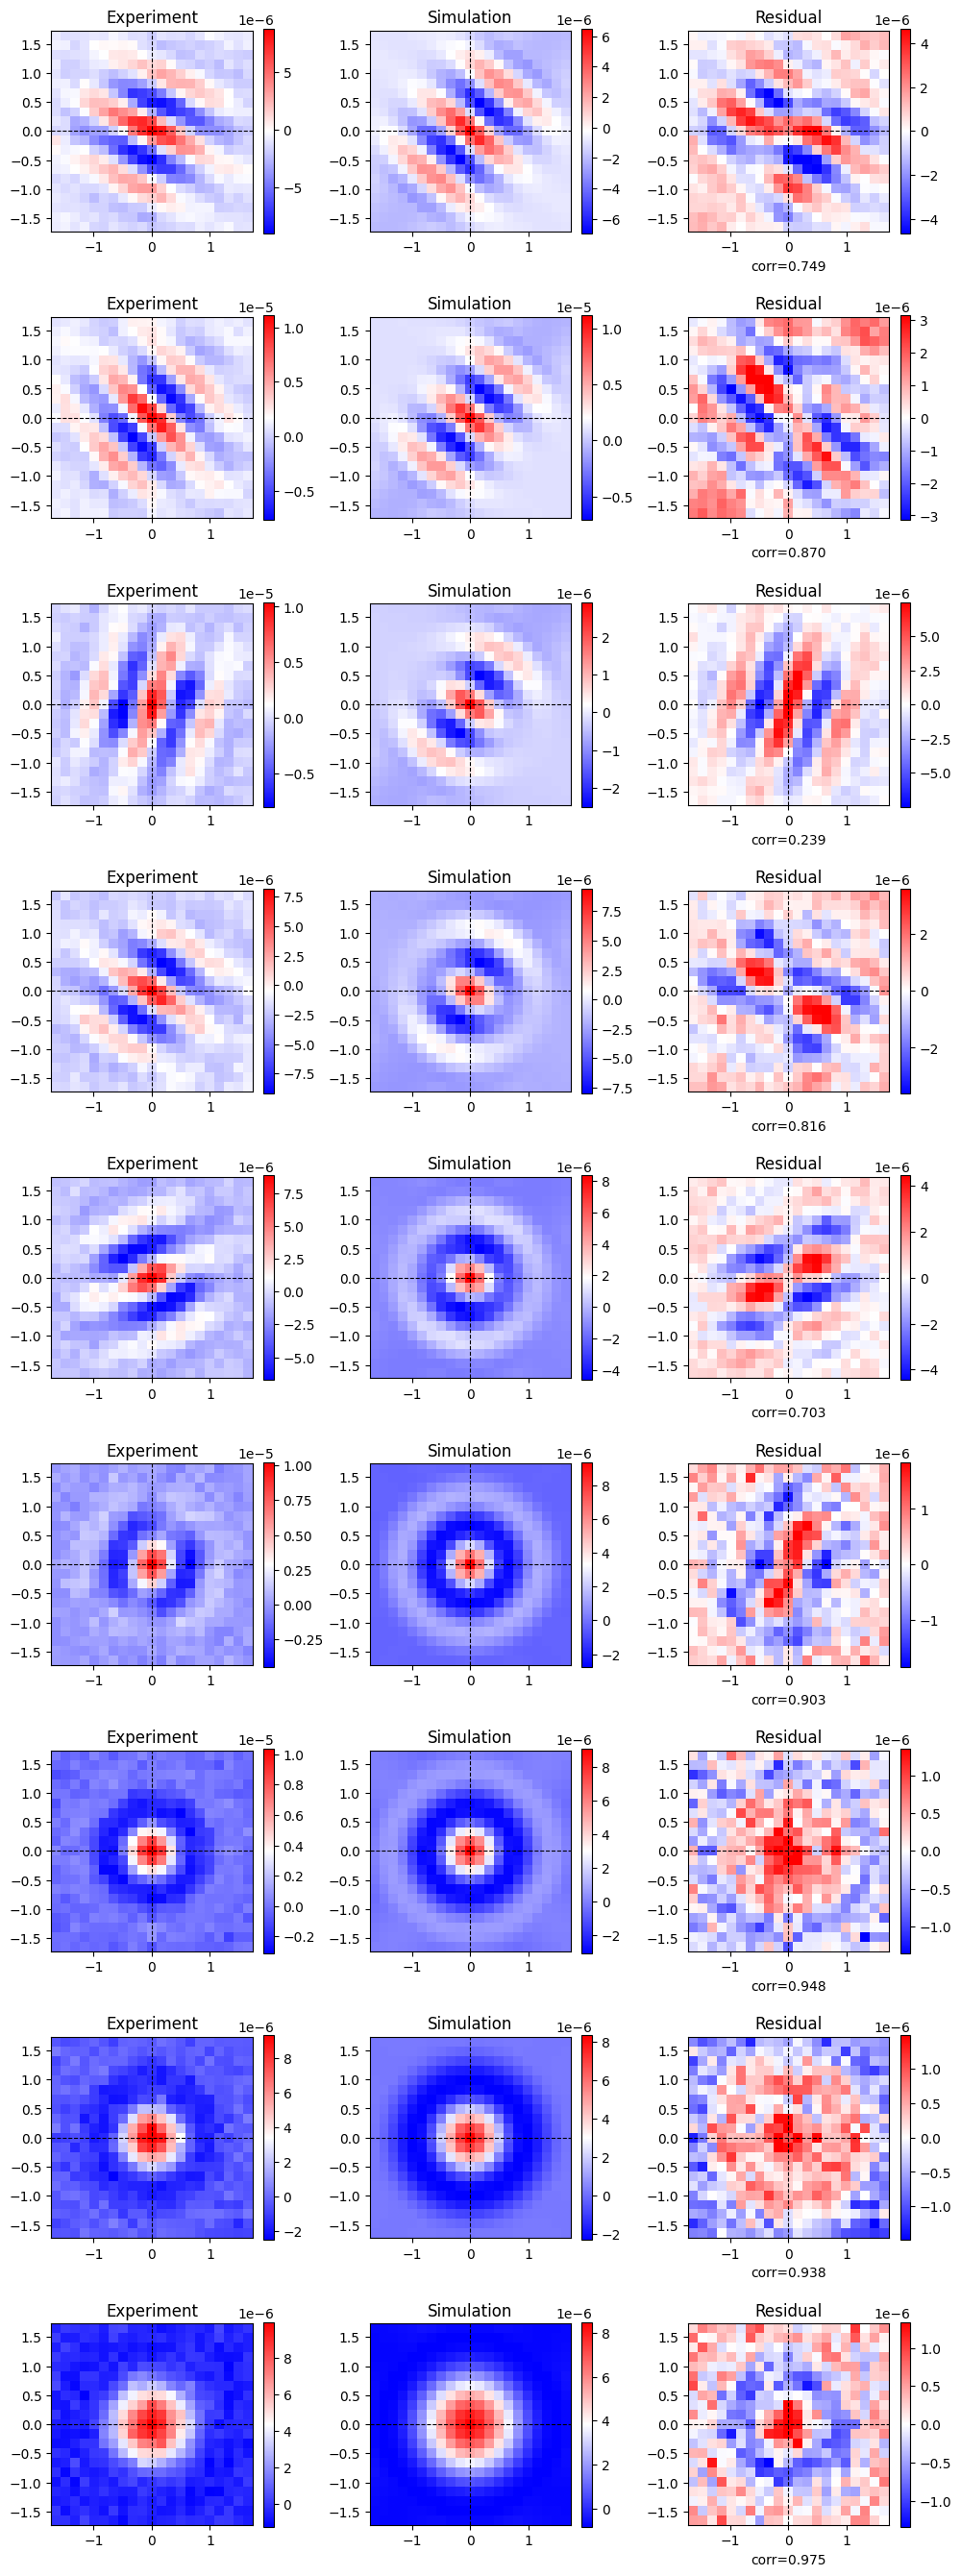


Average overlap: 0.7932760340445086
Cost: 0.3344578498656901


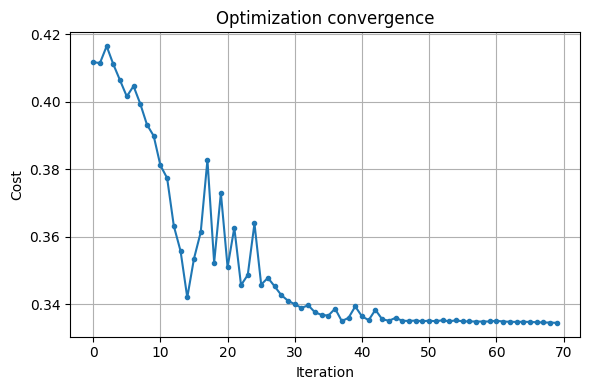

In [10]:
import numpy as np
from scipy.optimize import minimize

# ==========================================================
# Optimization history
# ==========================================================

history = []

# ==========================================================
# Cost function
# ==========================================================

def objective(params):

    T1, T2, detuning = params

    # ----------------------------------------------
    # Reject unphysical regions
    # ----------------------------------------------

    if T1 <= 1000:
        return 1e6

    if T2 <= 1000:
        return 1e6

    try:

        sim = simulate_characteristic_functions(
            T1=T1,
            T2=T2,
            detuning_MHz=detuning,
            angle_offset=initial_angle_offset,
            alpha=initial_alpha,
        )

        cost = residue_no_rotation(
            state_list,
            sim,
        )

    except Exception:

        return 1e6

    history.append(
        (
            T1,
            T2,
            detuning,
            cost,
        )
    )

    print(
        f"T1={T1/1000:7.2f} μs   "
        f"T2={T2/1000:7.2f} μs   "
        f"Δ={detuning:8.4f} MHz   "
        f"alpha={initial_alpha:8.4f} "
        f"cost={cost:.6f}"
    )

    return cost

# ==========================================================
# Initial guess
# ==========================================================

initial_guess = np.array([

    initial_T1,

    initial_T2,

    initial_detuning,

])

print("===================================")
print("Starting optimization")
print("===================================")

print(
    f"T1       = {initial_guess[0]/1000:.3f} μs"
)

print(
    f"T2       = {initial_guess[1]/1000:.3f} μs"
)

print(
    f"Detuning = {initial_guess[2]:.6f} MHz"
)

print(
    f"Angle offset fixed = {initial_angle_offset:.2f}°"
)

# ==========================================================
# Optimization
# ==========================================================

result = minimize(

    objective,

    initial_guess,

    method="Nelder-Mead",

    options={

        "maxiter":40,

        "disp":True,

        "xatol":100,

        "fatol":1e-5,

    },

)

best_T1, best_T2, best_detuning = result.x

print("\n===================================")
print("Optimization finished")
print("===================================")

print(f"T1       = {best_T1/1000:.3f} μs")
print(f"T2       = {best_T2/1000:.3f} μs")
print(f"Detuning = {best_detuning:.6f} MHz")
print(f"alpha = {initial_alpha:.2f}")
print(f"Cost     = {result.fun:.6f}")

# ==========================================================
# Simulate best solution
# ==========================================================

best_sim = simulate_characteristic_functions(

    T1=best_T1,

    T2=best_T2,

    detuning_MHz=best_detuning,

    angle_offset=initial_angle_offset,

    alpha=initial_alpha,

)

compare_experiment_simulation(

    state_list,

    best_sim,

    rotate_images = False

)

# ==========================================================
# Optimization history
# ==========================================================

history = np.asarray(history)

if len(history) > 0:

    import matplotlib.pyplot as plt

    plt.figure(figsize=(6,4))

    plt.plot(
        history[:,3],
        "-o",
        ms=3,
    )

    plt.xlabel("Iteration")

    plt.ylabel("Cost")

    plt.title("Optimization convergence")

    plt.grid(True)

    plt.tight_layout()

    plt.show()

I_raw​(x,y)=gχ(x,y)+b


File 1/9
File              : 12-11-32_ECD_decay_sweep.hdf5
Decay             : 500 ns
Gain              : -7.395447237e-06
Offset            : -9.158532773e-07
Conversion factor : -135218.3266
R²                : 0.560586
RMSE in χ units   : 0.223043

File 2/9
File              : 12-35-17_ECD_decay_sweep.hdf5
Decay             : 1 us
Gain              : -1.02293676e-05
Offset            : 9.322232612e-07
Conversion factor : -97757.75382
R²                : 0.757301
RMSE in χ units   : 0.126330

File 3/9
File              : 12-59-05_ECD_decay_sweep.hdf5
Decay             : 2.5 us
Gain              : -3.176652336e-06
Offset            : -2.646795746e-07
Conversion factor : -314796.8032
R²                : 0.056928
RMSE in χ units   : 0.750555

File 4/9
File              : 13-22-52_ECD_decay_sweep.hdf5
Decay             : 5 us
Gain              : -1.110318573e-05
Offset            : -1.690867844e-06
Conversion factor : -90064.24141
R²                : 0.665615
RMSE in χ units   : 0.11297

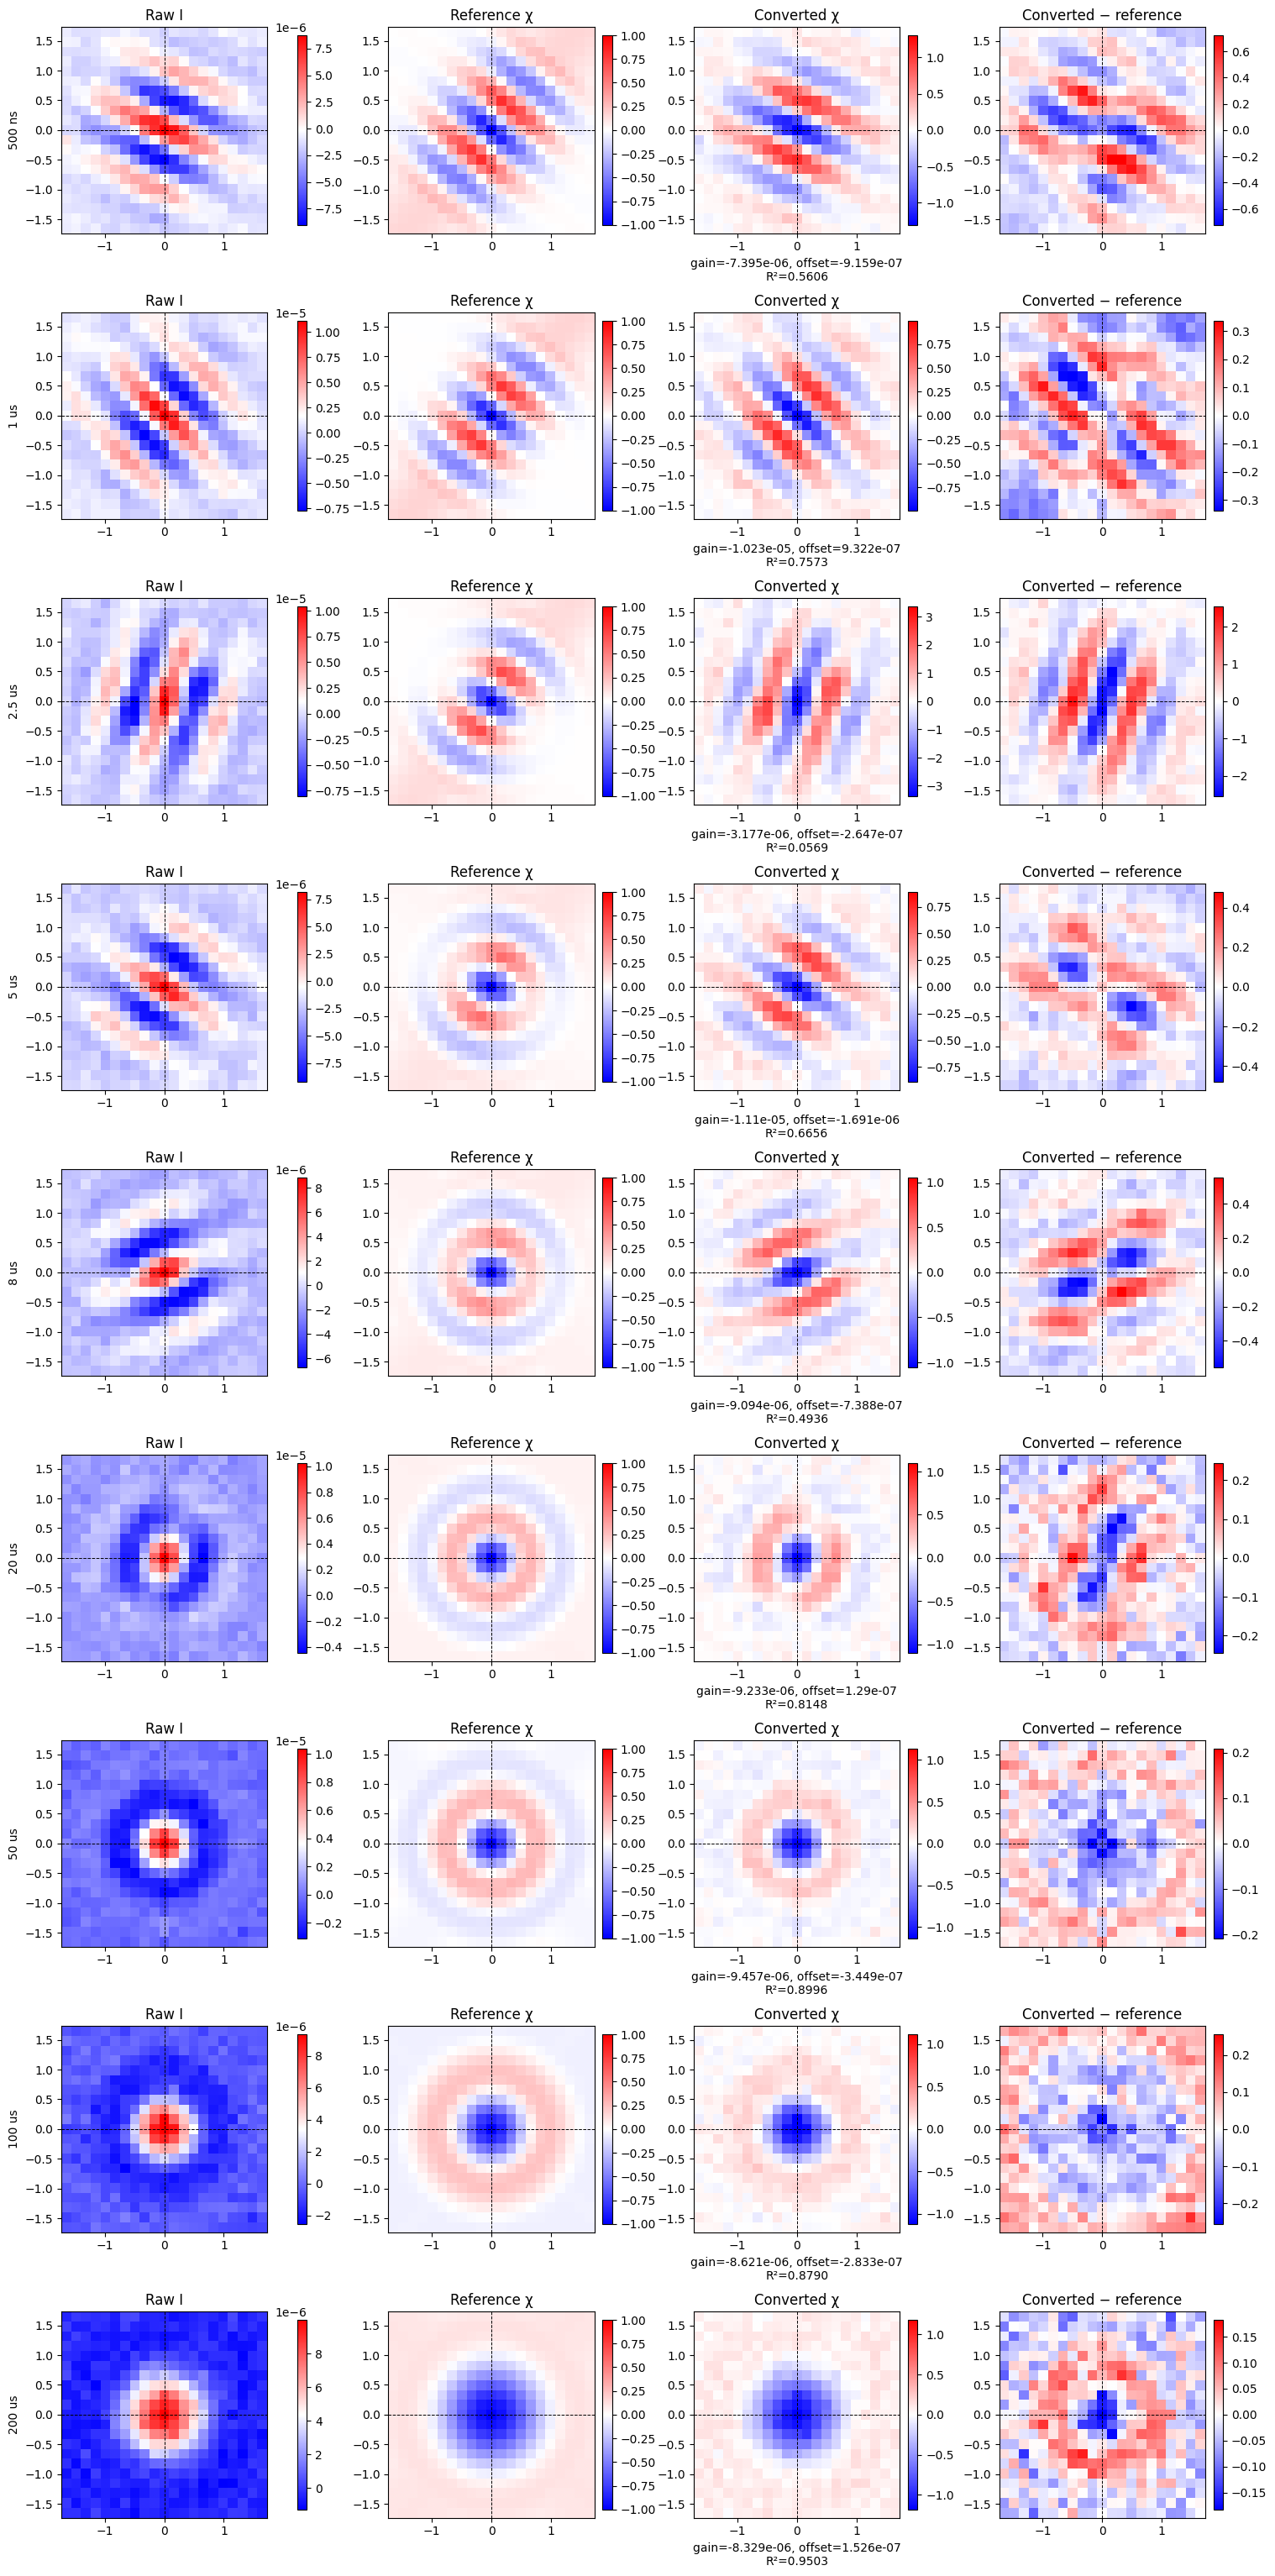

In [11]:
import csv
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np


# ==========================================================
# User settings
# ==========================================================

# Experimental raw/averaged images:
#     state_list[i]
#
# Reference characteristic functions:
#     best_sim[i]
#
# Normally use the best simulation from the final optimization.
reference_charfuncs = best_sim

# Fit only within this radius.
# This should be the same or similar to the fitting mask used above.
calibration_radius = 2.5

# Save calibrated characteristic-function HDF5 files
save_calibrated_files = True

calibrated_output_dir = Path(
    r"C:\Users\qcrew\Desktop\full-enjoy\data"
    r"\2026-07-13_coherent_stay_decay"
    r"\characteristic_function_calibrated"
)

# Save the calibration parameters to CSV
save_parameter_csv = True

parameter_csv_path = calibrated_output_dir / "conversion_parameters.csv"

# Whether existing output files can be replaced
overwrite_existing = True

# Plot raw data, reference, calibrated data, and residual
plot_calibration_results = True


# ==========================================================
# Check array lengths
# ==========================================================

experimental_data = np.asarray(state_list)
reference_charfuncs = np.asarray(reference_charfuncs)

if len(experimental_data) != len(reference_charfuncs):
    raise ValueError(
        "The number of experimental images and reference images differs:\n"
        f"experimental_data: {len(experimental_data)}\n"
        f"reference_charfuncs: {len(reference_charfuncs)}"
    )

if len(experimental_data) != len(collected_files_sorted):
    raise ValueError(
        "The number of experimental images and input files differs:\n"
        f"experimental_data: {len(experimental_data)}\n"
        f"collected_files_sorted: {len(collected_files_sorted)}"
    )


# ==========================================================
# Affine calibration fit
# ==========================================================

def fit_characteristic_calibration(
    raw_image,
    reference_image,
    fit_mask,
):
    """
    Fit:

        raw_image = gain * reference_image + offset

    The corresponding conversion is:

        characteristic_function
            = (raw_image - offset) / gain

    Returns
    -------
    calibrated_image : ndarray
        Raw image converted to characteristic-function scale.

    gain : float
        Multiplicative raw-readout gain.

    offset : float
        Additive raw-readout offset.

    conversion_factor : float
        Equal to 1 / gain.

    r_squared : float
        Coefficient of determination for the affine fit.

    rmse : float
        RMS error in characteristic-function units.
    """

    raw_image = np.asarray(raw_image, dtype=float)
    reference_image = np.asarray(reference_image, dtype=float)
    fit_mask = np.asarray(fit_mask, dtype=bool)

    if raw_image.shape != reference_image.shape:
        raise ValueError(
            f"Shape mismatch: raw={raw_image.shape}, "
            f"reference={reference_image.shape}"
        )

    if fit_mask.shape != raw_image.shape:
        raise ValueError(
            f"Mask shape {fit_mask.shape} does not match "
            f"image shape {raw_image.shape}."
        )

    valid = (
        fit_mask
        & np.isfinite(raw_image)
        & np.isfinite(reference_image)
    )

    raw_values = raw_image[valid]
    reference_values = reference_image[valid]

    if len(raw_values) < 3:
        raise ValueError(
            "Not enough finite calibration points inside the fit mask."
        )

    if np.std(reference_values) == 0:
        raise ValueError(
            "The reference characteristic function has zero variation "
            "inside the calibration mask."
        )

    # ------------------------------------------------------
    # Solve:
    #
    # raw = gain * reference + offset
    # ------------------------------------------------------

    design_matrix = np.column_stack(
        [
            reference_values,
            np.ones_like(reference_values),
        ]
    )

    gain, offset = np.linalg.lstsq(
        design_matrix,
        raw_values,
        rcond=None,
    )[0]

    if np.isclose(gain, 0):
        raise ValueError(
            "The fitted gain is approximately zero, so the data "
            "cannot be converted reliably."
        )

    conversion_factor = 1.0 / gain

    # Convert the complete image
    calibrated_image = (
        raw_image - offset
    ) * conversion_factor

    # ------------------------------------------------------
    # Fit quality
    # ------------------------------------------------------

    raw_fit_values = (
        gain * reference_values
        + offset
    )

    residual_raw = raw_values - raw_fit_values

    ss_res = np.sum(residual_raw**2)
    ss_tot = np.sum(
        (raw_values - np.mean(raw_values))**2
    )

    if ss_tot > 0:
        r_squared = 1.0 - ss_res / ss_tot
    else:
        r_squared = np.nan

    calibrated_values = calibrated_image[valid]

    rmse = np.sqrt(
        np.mean(
            (
                calibrated_values
                - reference_values
            )**2
        )
    )

    return {
        "calibrated_image": calibrated_image,
        "gain": float(gain),
        "offset": float(offset),
        "conversion_factor": float(conversion_factor),
        "r_squared": float(r_squared),
        "rmse": float(rmse),
        "number_of_fit_points": int(np.sum(valid)),
    }


# ==========================================================
# Fit each data file separately
# ==========================================================

calibration_results = []
calibrated_state_list = []

for index, (
    raw_image,
    reference_image,
    file_path,
    decay,
) in enumerate(
    zip(
        experimental_data,
        reference_charfuncs,
        collected_files_sorted,
        decay_sweep_sorted,
    )
):
    x = np.asarray(x_list[index])
    y = np.asarray(y_list[index])

    X, Y = np.meshgrid(x, y)

    calibration_mask = (
        X**2 + Y**2
    ) <= calibration_radius**2

    result = fit_characteristic_calibration(
        raw_image=raw_image,
        reference_image=reference_image,
        fit_mask=calibration_mask,
    )

    calibrated_image = result["calibrated_image"]
    calibrated_state_list.append(calibrated_image)

    result["input_file"] = str(file_path)
    result["filename"] = Path(file_path).name
    result["decay_ns"] = float(decay)

    calibration_results.append(result)

    if decay >= 1000:
        decay_label = f"{decay / 1000:g} us"
    else:
        decay_label = f"{decay:g} ns"

    print("\n" + "=" * 70)
    print(f"File {index + 1}/{len(experimental_data)}")
    print(f"File              : {Path(file_path).name}")
    print(f"Decay             : {decay_label}")
    print(f"Gain              : {result['gain']:.10g}")
    print(f"Offset            : {result['offset']:.10g}")
    print(
        "Conversion factor : "
        f"{result['conversion_factor']:.10g}"
    )
    print(f"R²                : {result['r_squared']:.6f}")
    print(
        "RMSE in χ units   : "
        f"{result['rmse']:.6f}"
    )

calibrated_state_list = np.asarray(
    calibrated_state_list
)


# ==========================================================
# Print conversion equations
# ==========================================================

print("\n")
print("=" * 90)
print("Conversion equations")
print("=" * 90)

for result in calibration_results:

    filename = result["filename"]
    gain = result["gain"]
    offset = result["offset"]
    factor = result["conversion_factor"]

    print(f"\n{filename}")
    print(
        f"  raw I = ({gain:.10g}) * chi "
        f"+ ({offset:.10g})"
    )
    print(
        f"  chi = (raw I - ({offset:.10g})) "
        f"* ({factor:.10g})"
    )


# ==========================================================
# Save parameter table as CSV
# ==========================================================

if save_parameter_csv:

    calibrated_output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    csv_columns = [
        "filename",
        "input_file",
        "decay_ns",
        "gain",
        "offset",
        "conversion_factor",
        "r_squared",
        "rmse",
        "number_of_fit_points",
    ]

    with open(
        parameter_csv_path,
        "w",
        newline="",
        encoding="utf-8",
    ) as csv_file:

        writer = csv.DictWriter(
            csv_file,
            fieldnames=csv_columns,
        )

        writer.writeheader()

        for result in calibration_results:

            writer.writerow(
                {
                    key: result[key]
                    for key in csv_columns
                }
            )

    print(
        f"\nSaved conversion parameters to:\n"
        f"{parameter_csv_path}"
    )


# ==========================================================
# Save calibrated HDF5 files
# ==========================================================

if save_calibrated_files:

    calibrated_output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    output_mode = (
        "w"
        if overwrite_existing
        else "x"
    )

    for index, result in enumerate(calibration_results):

        input_path = Path(
            result["input_file"]
        )

        output_filename = (
            input_path.stem
            + "_characteristic_calibrated.h5"
        )

        output_path = (
            calibrated_output_dir
            / output_filename
        )

        with h5py.File(
            output_path,
            output_mode,
        ) as outfile:

            outfile.create_dataset(
                "I",
                data=calibrated_state_list[index],
            )

            outfile.create_dataset(
                "x_displace",
                data=x_list[index],
            )

            outfile.create_dataset(
                "y_displace",
                data=y_list[index],
            )

            # Save the reference used for calibration
            outfile.create_dataset(
                "characteristic_reference",
                data=reference_charfuncs[index],
            )

            # Save calibration parameters
            outfile.attrs["source_file"] = str(
                input_path
            )

            outfile.attrs["calibration_model"] = (
                "raw_I = gain * characteristic_function + offset"
            )

            outfile.attrs["gain"] = result["gain"]
            outfile.attrs["offset"] = result["offset"]
            outfile.attrs["conversion_factor"] = (
                result["conversion_factor"]
            )
            outfile.attrs["r_squared"] = (
                result["r_squared"]
            )
            outfile.attrs["rmse_characteristic_units"] = (
                result["rmse"]
            )
            outfile.attrs["calibration_radius"] = (
                calibration_radius
            )
            outfile.attrs["decay_ns"] = (
                result["decay_ns"]
            )

        print(f"Saved: {output_path}")


# ==========================================================
# Plot calibration results
# ==========================================================

if plot_calibration_results:

    number_of_files = len(experimental_data)

    fig, axes = plt.subplots(
        number_of_files,
        4,
        figsize=(15, 3.4 * number_of_files),
        squeeze=False,
        constrained_layout=True,
    )

    for index in range(number_of_files):

        raw_image = experimental_data[index]
        reference_image = reference_charfuncs[index]
        calibrated_image = calibrated_state_list[index]

        residual = (
            calibrated_image
            - reference_image
        )

        images = [
            raw_image,
            reference_image,
            calibrated_image,
            residual,
        ]

        titles = [
            "Raw I",
            "Reference χ",
            "Converted χ",
            "Converted − reference",
        ]

        for column, (
            image,
            title,
        ) in enumerate(
            zip(images, titles)
        ):
            ax = axes[index, column]

            if column == 0:
                im = ax.pcolormesh(
                    x_list[index],
                    y_list[index],
                    image,
                    shading="auto",
                    cmap="bwr",
                )

            else:
                vmax = np.nanmax(
                    np.abs(image)
                )

                if not np.isfinite(vmax) or vmax == 0:
                    vmax = 1.0

                im = ax.pcolormesh(
                    x_list[index],
                    y_list[index],
                    image,
                    shading="auto",
                    cmap="bwr",
                    vmin=-vmax,
                    vmax=vmax,
                )

            ax.axvline(
                0,
                color="k",
                linestyle="--",
                linewidth=0.7,
            )

            ax.axhline(
                0,
                color="k",
                linestyle="--",
                linewidth=0.7,
            )

            ax.set_aspect(
                "equal",
                adjustable="box",
            )

            ax.set_title(title)

            fig.colorbar(
                im,
                ax=ax,
                fraction=0.046,
                pad=0.04,
            )

        decay = decay_sweep_sorted[index]

        if decay >= 1000:
            decay_label = f"{decay / 1000:g} us"
        else:
            decay_label = f"{decay:g} ns"

        axes[index, 0].set_ylabel(
            decay_label
        )

        result = calibration_results[index]

        axes[index, 2].set_xlabel(
            f"gain={result['gain']:.4g}, "
            f"offset={result['offset']:.4g}\n"
            f"R²={result['r_squared']:.4f}"
        )

    plt.show()